In [1]:
## testing new cleaned version for raw + spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

In [2]:
run_start = 11727
run_end   = 12684

base_path = "F:/LANL/processed_data/"

outlier_thresh = 10000
start_b = 2300

In [3]:
def discover_all_data(base_path, run_start, run_end):
    folderslist = []
    runslist_raw = []
    runslist_opt = []
    runslist_pulseadd_D = []
    runslist_pulseadd_U = []

    print("\n=== Discovering data ===")

    for folder in sorted(os.listdir(base_path)):
        if not folder.startswith("runs"):
            continue

        # parse folder range
        try:
            f_start, f_end = folder.replace("runs", "").split("-")
            f_start, f_end = int(f_start), int(f_end)
        except:
            print(f"Skipping {folder} (bad naming)")
            continue

        # skip irrelevant folders
        if f_end < run_start or f_start > run_end:
            continue

        fpath = os.path.join(base_path, folder)

        print(f"\nReading folder: {folder}")

        raw_dir = os.path.join(fpath, "asym_raw_D")
        pulseadd_D_dir = os.path.join(fpath, "pulseadd_D")
        pulseadd_U_dir = os.path.join(fpath, "pulseadd_U")

        if not os.path.exists(raw_dir):
            print("  No asym_raw_D → skipping")
            continue

        runs_raw = []
        runs_opt = []
        runs_D = []
        runs_U = []

        for fname in sorted(os.listdir(raw_dir)):
            if fname.endswith("_raw_D.h5") and not fname.endswith("_optimized.h5"):
                run = int(fname.split('_')[0])
                if run_start <= run <= run_end:
                    runs_raw.append(str(run).zfill(5))
            elif fname.endswith("_raw_D_optimized.h5"):
                run = int(fname.split('_')[0])
                if run_start <= run <= run_end:
                    runs_opt.append(str(run).zfill(5))

        # --- pulseadd ---
        if os.path.exists(pulseadd_D_dir):
            for fname in os.listdir(pulseadd_D_dir):
                if fname.endswith("_pulseadd_D.h5"):
                    run = int(fname.split('_')[0])
                    if run_start <= run <= run_end:
                        runs_D.append(str(run).zfill(5))

        if os.path.exists(pulseadd_U_dir):
            for fname in os.listdir(pulseadd_U_dir):
                if fname.endswith("_pulseadd_U.h5"):
                    run = int(fname.split('_')[0])
                    if run_start <= run <= run_end:
                        runs_U.append(str(run).zfill(5))

        if len(runs_raw) == 0:
            print("  No matching runs in range")
            continue

        print(f"  Raw runs: {min(runs_raw)} → {max(runs_raw)} ({len(runs_raw)})")
        print(f"  Pulseadd D: {len(runs_D)} | U: {len(runs_U)}")

        folderslist.append(folder)
        runslist_raw.append(sorted(runs_raw))
        runslist_opt.append(sorted(runs_opt))
        runslist_pulseadd_D.append(sorted(runs_D))
        runslist_pulseadd_U.append(sorted(runs_U))

    return (folderslist,
            runslist_raw,
            runslist_opt,
            runslist_pulseadd_D,
            runslist_pulseadd_U)

In [4]:
(folderslist,
 runslist_raw,
 runslist_opt,
 runslist_pulseadd_D,
 runslist_pulseadd_U) = discover_all_data(base_path, run_start, run_end)


=== Discovering data ===

Reading folder: runs11727-12033
  Raw runs: 11727 → 12032 (306)
  Pulseadd D: 307 | U: 307

Reading folder: runs12034-12363
  Raw runs: 12034 → 12363 (330)
  Pulseadd D: 330 | U: 330

Reading folder: runs12364-12684
  Raw runs: 12364 → 12684 (318)
  Pulseadd D: 318 | U: 318


In [5]:
runs_D = set()
runs_U = set()
runs_D_opt = set()
runs_U_opt = set()

for f in range(len(folderslist)):

    runs_D.update(runslist_pulseadd_D[f])   # use same structure
    runs_U.update(runslist_pulseadd_U[f])

    runs_D_opt.update(runslist_opt[f])
    runs_U_opt.update(runslist_opt[f])

# final usable runs
common_runs = sorted(list(runs_D & runs_U & runs_D_opt & runs_U_opt))

print("Total runs:", len(common_runs))

Total runs: 954


In [6]:
def load_run_file(path):
    return h5py.File(path, 'r')

In [7]:
# --- first: determine sizes from ONE file ---
test_run = common_runs[0]

for f in range(len(folderslist)):
    if test_run in runslist_raw[f]:
        fpath = os.path.join(base_path, folderslist[f])
        rawD = load_run_file(os.path.join(fpath, "asym_raw_D", test_run + "_raw_D.h5"))
        rawU = load_run_file(os.path.join(fpath, "asym_raw_U", test_run + "_raw_U.h5"))

        ch_D_keys = sorted([k for k in rawD.keys() if k != 'xs '], key=lambda x: int(x.split('_')[1]))
        ch_U_keys = sorted([k for k in rawU.keys() if k != 'xs '], key=lambda x: int(x.split('_')[1]))

        xs = rawD['xs '][:]
        n_points = len(xs)

        n_ch_D = len(ch_D_keys)
        n_ch_U = len(ch_U_keys)
        n_runs = len(common_runs)

        break


# --- allocate FINAL arrays directly (no transpose later) ---
raw_D = np.zeros((n_ch_D, n_runs, n_points), dtype=np.float64)
raw_U = np.zeros((n_ch_U, n_runs, n_points), dtype=np.float64)

raw_D_opt = np.zeros((n_ch_D, n_runs, n_points), dtype=np.float64)
raw_U_opt = np.zeros((n_ch_U, n_runs, n_points), dtype=np.float64)

run_labels = np.zeros(n_runs, dtype=np.int32)
all_sequences = np.zeros(n_runs, dtype=np.int32)


# --- fill arrays ---
for r, run in enumerate(common_runs):

    for f in range(len(folderslist)):
        if run in runslist_raw[f]:

            fpath = os.path.join(base_path, folderslist[f])

            rawD = load_run_file(os.path.join(fpath, "asym_raw_D", run + "_raw_D.h5"))
            rawU = load_run_file(os.path.join(fpath, "asym_raw_U", run + "_raw_U.h5"))

            rawD_opt = load_run_file(os.path.join(fpath, "asym_raw_D", run + "_raw_D_optimized.h5"))
            rawU_opt = load_run_file(os.path.join(fpath, "asym_raw_U", run + "_raw_U_optimized.h5"))

            all_sequences[r] = rawD.attrs['sequences']

            for ch in range(n_ch_D):
                raw_D[ch, r, :] = rawD[ch_D_keys[ch]]['asym_raw'][:]
                raw_D_opt[ch, r, :] = rawD_opt[ch_D_keys[ch]]['asym_raw'][:]

            for ch in range(n_ch_U):
                raw_U[ch, r, :] = rawU[ch_U_keys[ch]]['asym_raw'][:]
                raw_U_opt[ch, r, :] = rawU_opt[ch_U_keys[ch]]['asym_raw'][:]

            run_labels[r] = int(run)

            break

print("raw_D:", raw_D.shape)
print("raw_U:", raw_U.shape)

raw_D: (13, 954, 8992)
raw_U: (13, 954, 8992)


In [8]:
print("all_sequences shape:", all_sequences.shape)
print("Total sequences:", np.sum(all_sequences))

all_sequences shape: (954,)
Total sequences: 12390


In [9]:
# remove ch_24 from D BEFORE stacking
raw_D_no24 = raw_D[:-1]
raw_D_opt_no24 = raw_D_opt[:-1]

all_raw = np.vstack((raw_D_no24, raw_U))
all_raw_opt = np.vstack((raw_D_opt_no24, raw_U_opt))

print("all_raw:", all_raw.shape)
print("all_raw_opt:", all_raw_opt.shape)

all_raw: (25, 954, 8992)
all_raw_opt: (25, 954, 8992)


In [10]:
del raw_D, raw_U, raw_D_opt, raw_U_opt

In [11]:
outlier_thresh = 5000
start_b = 2300

problem_channels = []
problem_runs = []

for r in range(all_raw.shape[1]):   # runs

    for ch in range(all_raw.shape[0]):  # channels

        if np.max(np.abs(all_raw[ch, r, start_b:])) >= outlier_thresh:
            problem_channels.append(ch)
            problem_runs.append(r)
            break  # same as your original logic

outlier_runs = np.unique(problem_runs)

print("Outlier run indices:", outlier_runs)
print("Channels triggering them:", problem_channels)

for r in outlier_runs:
    ch_list = [problem_channels[i] for i in range(len(problem_runs)) if problem_runs[i] == r]
    print(f"Run index {r} triggered by channel(s): {np.unique(ch_list)}")

Outlier run indices: [109]
Channels triggering them: [3]
Run index 109 triggered by channel(s): [3]


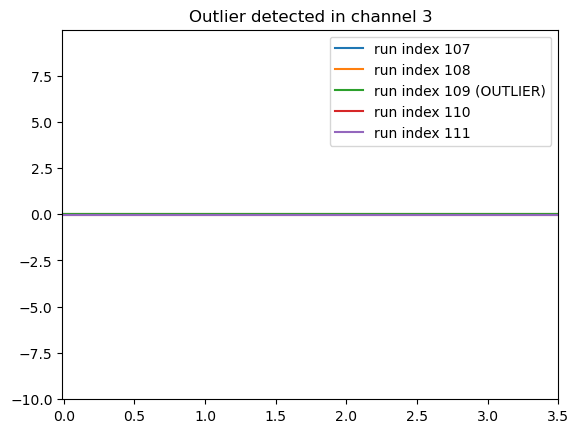

In [12]:
if len(outlier_runs) > 0:

    r = outlier_runs[0]

    # find channel(s) that triggered it
    ch_list = [problem_channels[i] for i in range(len(problem_runs)) if problem_runs[i] == r]
    ch = ch_list[0]  # just plot the first triggering channel

    idxs = [r-2, r-1, r, r+1, r+2]
    idxs = [i for i in idxs if i >= 0 and i < all_raw.shape[1]]

    plt.figure()

    for i in idxs:
        label = f"run index {i}"
        if i == r:
            label += " (OUTLIER)"
        plt.plot(xs, all_raw[ch, i], label=label)
        

    plt.axhline(outlier_thresh, linestyle='--', color='k')
    plt.axhline(-outlier_thresh, linestyle='--', color='k')
    baseish = np.mean(all_raw[ch, 200, start_b:]) ## just a random run
    plt.ylim(baseish-10, baseish+10)
    plt.xlim(-0.01, 3.5)

    plt.title(f"Outlier detected in channel {ch}")
    plt.legend()
    plt.show()

In [13]:
# keep original copies if not already saved
if "all_raw_og" not in globals():
    all_raw_og = np.copy(all_raw)
if "all_raw_opt_og" not in globals():
    all_raw_opt_og = np.copy(all_raw_opt)

# reset before deletion (so cell is re-runnable)
all_raw = np.copy(all_raw_og)
all_raw_opt = np.copy(all_raw_opt_og)

if len(outlier_runs) > 0:
    all_raw = np.delete(all_raw, outlier_runs, axis=1)
    all_raw_opt = np.delete(all_raw_opt, outlier_runs, axis=1)

    print(f"Deleted {len(outlier_runs)} runs")
    print("New shape raw:", all_raw.shape)
    print("New shape opt:", all_raw_opt.shape)
else:
    print("No runs removed")

Deleted 1 runs
New shape raw: (25, 953, 8992)
New shape opt: (25, 953, 8992)


##### now pulses-added for spectra

In [14]:
# --- determine pulse shape from first run ---
test_run = common_runs[0]

for f in range(len(folderslist)):
    if test_run in runslist_pulseadd_D[f]:
        fpath = os.path.join(base_path, folderslist[f])

        pulseD = load_run_file(os.path.join(fpath, "pulseadd_D", test_run + "_pulseadd_D.h5"))
        pulseU = load_run_file(os.path.join(fpath, "pulseadd_U", test_run + "_pulseadd_U.h5"))

        ch_D_keys = [k for k in pulseD.keys() if k.startswith('ch_')]
        ch_D_keys = sorted(ch_D_keys, key=lambda x: int(x.split('_')[1]))
        ch_U_keys = [k for k in pulseU.keys() if k.startswith('ch_')]
        ch_U_keys = sorted(ch_U_keys, key=lambda x: int(x.split('_')[1]))

        sample = pulseD[ch_D_keys[0] + '/added_pulses/' + ch_D_keys[0]][:]
        n_points = len(sample)

        n_ch_D = len(ch_D_keys)
        n_ch_U = len(ch_U_keys)
        n_runs = len(common_runs)

        break


# --- allocate ---
all_pulse_D = np.zeros((n_ch_D, n_runs, n_points), dtype=np.float64)
all_pulse_U = np.zeros((n_ch_U, n_runs, n_points), dtype=np.float64)

pulse_counts = np.zeros(n_runs, dtype=np.int32)


# --- fill ---
for r, run in enumerate(common_runs):

    for f in range(len(folderslist)):
        if run in runslist_pulseadd_D[f]:

            fpath = os.path.join(base_path, folderslist[f])

            pulseD = load_run_file(os.path.join(fpath, "pulseadd_D", run + "_pulseadd_D.h5"))
            pulseU = load_run_file(os.path.join(fpath, "pulseadd_U", run + "_pulseadd_U.h5"))

            for ch in range(n_ch_D):
                data = pulseD[ch_D_keys[ch] + '/added_pulses/' + ch_D_keys[ch]][:]
                all_pulse_D[ch, r, :] = pulseD[ch_D_keys[ch] + '/added_pulses/' + ch_D_keys[ch]][:]

            for ch in range(n_ch_U):
                data = pulseU[ch_U_keys[ch] + '/added_pulses/' + ch_U_keys[ch]][:]
                all_pulse_U[ch, r, :] = pulseU[ch_U_keys[ch] + '/added_pulses/' + ch_U_keys[ch]][:]

            pulse_counts[r] = data.shape[0]  # number of pulses

            break


# --- combine like raw ---
all_pulse = np.vstack((all_pulse_D[:-1], all_pulse_U))

print("all_pulse shape:", all_pulse.shape)

all_pulse shape: (25, 954, 8992)


In [15]:
del all_pulse_D, all_pulse_U

In [16]:
if "all_pulse_og" not in globals():
    all_pulse_og = np.copy(all_pulse)

all_pulse = np.copy(all_pulse_og)

if len(outlier_runs) > 0:
    all_pulse = np.delete(all_pulse, outlier_runs, axis=1)

print("Raw asym shape:", all_raw.shape)
print("Spectras shape:", all_pulse.shape)

all_sequences = np.delete(all_sequences, outlier_runs)
print("sequences shape:", all_sequences.shape)

Raw asym shape: (25, 953, 8992)
Spectras shape: (25, 953, 8992)
sequences shape: (953,)


In [17]:
### sum over runs
sum_ch_raw = []
sum_ch_opt = []
sum_ch_pulse = []

for ch in range(all_raw.shape[0]):

    ch_raw = np.sum(all_raw[ch, :], axis=0)
    ch_opt = np.sum(all_raw_opt[ch, :], axis=0)
    ch_pulse = np.sum(all_pulse[ch, :], axis=0)

    sum_ch_raw.append(ch_raw)
    sum_ch_opt.append(ch_opt)
    sum_ch_pulse.append(ch_pulse)

sum_ch_raw = np.array(sum_ch_raw)
sum_ch_opt = np.array(sum_ch_opt)
sum_ch_pulse = np.array(sum_ch_pulse)

print("sum_ch_raw:", sum_ch_raw.shape)
print("sum_ch_pulse:", sum_ch_pulse.shape)

sum_ch_raw: (25, 8992)
sum_ch_pulse: (25, 8992)


In [18]:
## normalize them

total_sequences = np.sum(all_sequences)
n_runs = all_raw.shape[1]

# asymmetry
sum_ch_raw = sum_ch_raw / total_sequences
sum_ch_opt = sum_ch_opt / total_sequences

# pulseadd
sum_ch_pulse = sum_ch_pulse / n_runs

In [19]:
nai_channels = list(range(sum_ch_raw.shape[0] - 1))
li6_channel = sum_ch_raw.shape[0] - 1

# NaI combined
allNaI_raw = np.sum(sum_ch_raw[nai_channels], axis=0) / len(nai_channels)
allNaI_opt = np.sum(sum_ch_opt[nai_channels], axis=0) / len(nai_channels)
allNaI_pulse = np.sum(sum_ch_pulse[nai_channels], axis=0) / len(nai_channels)

# 6Li
allLi6_raw = sum_ch_raw[li6_channel]
allLi6_opt = sum_ch_opt[li6_channel]
allLi6_pulse = sum_ch_pulse[li6_channel]

##### now plot

In [20]:
## helpers
from functools import reduce

def factors(n):
    return set(reduce(list.__add__,
        ([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))

def rebin(ys, xs, rebinfactor):
    outys = ys.reshape(-1, rebinfactor).mean(axis=1)
    outxs = xs.reshape(-1, rebinfactor).mean(axis=1)
    return outys, outxs

In [21]:
# Sample window
r1 = 2001
r2 = 8501

ch = 1  # channel index

x = xs[r1:r2]

# --- pulseadd ---
y1 = sum_ch_pulse[ch][r1:r2]

# --- asymmetry ---
#  (already normalized)
y2 = sum_ch_raw[ch][r1:r2] * -1   # flip sign for plotting

In [22]:
rebinfactors = np.sort(np.array(list(factors(len(y2)))))
print(f'possible factors are ', rebinfactors)

rebinf = rebinfactors[5]
print(f'using factor {rebinf}')

y2_rebin, x_rebin = rebin(y2, x, rebinf)

possible factors are  [   1    2    4    5   10   13   20   25   26   50   52   65  100  125
  130  250  260  325  500  650 1300 1625 3250 6500]
using factor 13


In [33]:
# from cycler import cycler
# import matplotlib as mpl

# mpl.rcParams['axes.prop_cycle'] = cycler(color=[
#     '#0072B2',
#     '#D55E00',
#     '#009E73',
#     '#CC79A7',
#     '#F0E442',
#     '#56B4E9',
# ])

# plt.rcParams.update({
#     'font.size': 8,
#     'font.family': 'sans-serif',
#     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
#     'text.usetex': False,
#     'figure.figsize': (3.5, 2.7),
#     'figure.dpi': 300,
#     'savefig.format': 'pdf',
#     'savefig.bbox': 'tight',
#     'axes.labelsize': 8,
#     'axes.titlesize': 8,
#     'xtick.labelsize': 6,
#     'ytick.labelsize': 6,
#     'legend.fontsize': 6,
#     'lines.linewidth': 0.8,
#     'lines.markersize': 3.0,
#     'axes.linewidth': 0.8,
#     'xtick.major.width': 0.8,
#     'ytick.major.width': 0.8,
#     'xtick.direction': 'in',
#     'ytick.direction': 'in',
#     'grid.linewidth': 0.5,
# })
# print('updated rcparams')

from cycler import cycler
import matplotlib as mpl

# Bright, colorblind-safe, no yellow
mpl.rcParams['axes.prop_cycle'] = cycler(color=[
    '#0072B2',  # blue
    '#D55E00',  # red-orange
    '#009E73',  # green
    '#CC79A7',  # magenta
    '#56B4E9',  # light blue
])

plt.rcParams.update({
    'font.size': 6,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'text.usetex': False,
    'figure.figsize': (3.0, 2.2),
    'figure.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'axes.labelsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 4,
    'ytick.labelsize': 4,
    'legend.fontsize': 4,
    # slightly thicker for clarity
    'lines.linewidth': 0.8,
    'lines.markersize': 2.5,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.linewidth': 0.3,
})

print('updated rcparams (no yellow, high contrast)')

updated rcparams (no yellow, high contrast)


In [34]:
%matplotlib qt
# %matplotlib inline

fig, ax1 = plt.subplots()

# --- spectrum ---
ax1.plot(x, y1, label=f'Pulse spectrum ch_{ch:02d}', color='C0')
ax1.set_ylabel(r'Counts [arb.]', color='C0')
ax1.set_xlabel('ToF [ms]')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.set_yscale('log')


# --- asymmetry ---
ax2 = ax1.twinx()
ax2.plot(x_rebin, y2_rebin, ls='-', label='"Raw" Asymmetry', color='C1')
ax2.set_ylabel('Asymmetry [absolute]', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# limits
# ax1.set_ylim(-0.01e9, 0.5e9)
ax2.set_ylim(-0.004, 0.008)

# legend
fig.legend(loc="upper right", bbox_to_anchor=(0.89, 0.87))

# grid
ax1.grid(True, which='major', axis='both', alpha=0.75, ls=':')
ax1.minorticks_on()

plt.show()

In [24]:
# choose window + channel
r1 = 2001
r2 = 8501
ch = 1

x = xs[r1:r2]

# already normalized earlier → DO NOT divide again
y_raw = sum_ch_raw[ch][r1:r2] * -1
y_opt = sum_ch_opt[ch][r1:r2] * -1

%matplotlib qt
# %matplotlib inline

plt.figure()

plt.plot(x, y_raw, label='Raw', color='C0')
plt.plot(x, y_opt, '--', label='Optimized', color='C1')

plt.xlabel('ToF [ms]')
plt.ylabel('Asymmetry [absolute]')
plt.title(f'Asymmetry comparison (no rebin) ch_{ch:02d}')

# plt.xlim(-0.01, 3.5)
# plt.ylim(-0.004, 0.006)

plt.legend()
plt.grid(True, which='major', axis='both', alpha=0.75, ls=':')
plt.show()

In [25]:
# rebin factor (choose manually or from factors)
rebinfactors = np.sort(np.array(list(factors(len(y_raw)))))
print("possible factors:", rebinfactors)

rebinf = rebinfactors[5]   # adjust as needed
print("using factor:", rebinf)

# rebin both
y_raw_rebin, x_rebin = rebin(y_raw, x, rebinf)
y_opt_rebin, _ = rebin(y_opt, x, rebinf)

plt.figure()

plt.plot(x_rebin, y_raw_rebin, label='Raw (rebinned)', color='C0')
plt.plot(x_rebin, y_opt_rebin, '--', label='Optimized (rebinned)', color='C1')

plt.xlabel('ToF [ms]')
plt.ylabel('Asymmetry [absolute]')
plt.title(f'Asymmetry comparison (rebinned) ch_{ch:02d}')
plt.plot(x, y_opt - y_raw, label='Difference')

# plt.xlim(-0.01, 3.5)
# plt.ylim(-0.004, 0.006)

plt.legend()
plt.grid(True, which='major', axis='both', alpha=0.75, ls=':')
plt.show()

possible factors: [   1    2    4    5   10   13   20   25   26   50   52   65  100  125
  130  250  260  325  500  650 1300 1625 3250 6500]
using factor: 13


In [26]:
# difference obvious::

plt.plot(x, y_opt - y_raw, label='Difference')